# 1.Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2.Load Dataset

In [4]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# 3.Check Missing Values

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# 4.Create new features

In [7]:
# BMI Category
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df["BMI_Category"] = df["bmi"].apply(bmi_category)
df.head()

,age,sex,bmi,children,smoker,region,charges,BMI_Category
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight


In [8]:
# Age group
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 50:
        return "Adult"
    else:
        return "Senior"

df["Age_Group"] = df["age"].apply(age_group)

df.head()

,age,sex,bmi,children,smoker,region,charges,BMI_Category,Age_Group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,Young
1,18,male,33.770,1,no,southeast,1725.55230,Obese,Young
2,28,male,33.000,3,no,southeast,4449.46200,Obese,Young
3,33,male,22.705,0,no,northwest,21984.47061,Normal,Adult
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,Adult


In [9]:
# Interaction: smoker × BMI
df["smoker_bmi"] = df["bmi"] * (df["smoker"] == "yes")
df.head()

,age,sex,bmi,children,smoker,region,charges,BMI_Category,Age_Group,smoker_bmi
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,Young,27.9
1,18,male,33.770,1,no,southeast,1725.55230,Obese,Young,0.0
2,28,male,33.000,3,no,southeast,4449.46200,Obese,Young,0.0
3,33,male,22.705,0,no,northwest,21984.47061,Normal,Adult,0.0
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,Adult,0.0


# 5.Detect and handle outliers

In [10]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


df = df[(df["charges"] >= lower) & (df["charges"] <= upper)]

In [11]:
df = pd.get_dummies(df, drop_first=True)

# 6.Define Features and Target

In [12]:
X = df.drop("charges", axis=1)

y = df["charges"]

# 7.Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8.Train Model

In [14]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

# 9.Prediction

In [15]:
y_pred = lr.predict(X_test)

# 10.Evaluate Model

In [16]:
# MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 2783.118950229294


In [17]:
# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 5170.5492475260935


In [18]:
# R-squared score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.5714258902437502


# 11.Train Non-Linear Model

In [ ]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

# 12.Evaluate Decision Tree

In [20]:
print("Tree MAE:", mean_absolute_error(y_test, y_pred_tree))
print("Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))
print("Tree R2:", r2_score(y_test, y_pred_tree))

Tree MAE: 3056.8752838083333
Tree RMSE: 6594.623841010362
Tree R2: 0.3028397284612898


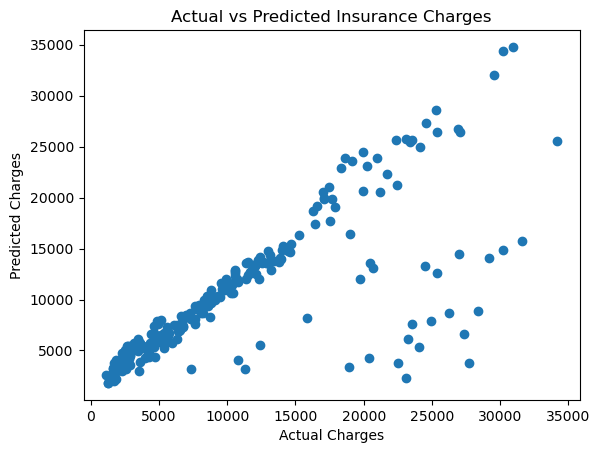

In [21]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

In [22]:
import pickle

pickle.dump(lr, open("insurance_model.pkl", "wb"))